# Probability 

## Basics of Probability

### 1. Write a Python program to simulate the following scenarios:  

- **a.** Tossing a coin 10,000 times and calculating the experimental probability of heads and tails.  


In [2]:
import random

trials = 10000
heads = 0
tails = 0

for _ in range(trials):
    toss = random.choice(['H', 'T'])
    if toss == 'H':
        heads += 1
    else:
        tails += 1

print("Probability of Heads:", heads / trials)
print("Probability of Tails:", tails / trials)

Probability of Heads: 0.4995
Probability of Tails: 0.5005


- **b.** Rolling two dice and computing the probability of getting a sum of 7.
   
    **Steps** 
    - a. Use Python's random module for simulations.  
    - b. Implement loops for repeated trials.  
    - c. Track outcomes and compute probabilities.  

In [5]:
import random

trials = 100000
count = 0

for _ in range(trials):
    die1 = random.randint(1, 6)
    die2 = random.randint(1, 6)
    
    if die1 + die2 == 7:
        count += 1

probability = count / trials

print("Trials:", trials)
print("Number of times sum = 7:", count)
print("Estimated Probability:", probability)

Trials: 100000
Number of times sum = 7: 16569
Estimated Probability: 0.16569


### **2.** Write a function to estimate the probability of getting at least one "6" in 10 rolls of a fair die.  
**Steps**  
- a. Simulate rolling a die 10 times using a loop.  
- b. Track trials where at least one "6" occurs.  
- c. Calculate the proportion of successful trials.


In [7]:
import random

def probability_at_least_one_six(trials):
    success_count = 0

    for i in range(trials):
        found_six = False

        # Roll the die 10 times
        for i in range(10):
            roll = random.randint(1, 6)
            if roll == 6:
                found_six = True
                break  # stop early if 6 is found

        if found_six:
            success_count += 1

    probability = success_count / trials
    return probability


# Example usage
trials = 100000
result = probability_at_least_one_six(trials)

print("Trials:", trials)
print("Estimated Probability of at least one 6:", result)

Trials: 100000
Estimated Probability of at least one 6: 0.83838


## Conditional Probability and Bayes' Theorem

### 3. A bag contains 5 red, 7 green, and 8 blue balls. A ball is drawn randomly, its color noted, and it is put back into the bag. If this process is repeated 1000 times, write a Python program to estimate:  
- a. The probability of drawing a red ball given that the previous ball was blue.  
- b. Verify Bayes' theorem with the simulation results.  


**Steps**  
- a. Use random sampling to simulate the process.  
- b. Compute conditional probabilities directly from the data.  


In [8]:
import random

def simulate_balls(trials):
    # Bag setup
    bag = ["R"] * 5 + ["G"] * 7 + ["B"] * 8

    prev_blue_count = 0
    red_after_blue = 0

    blue_count = 0
    red_count = 0

    # First draw (to initialize previous ball)
    prev = random.choice(bag)

    for _ in range(trials):
        current = random.choice(bag)

        # Count totals
        if current == "B":
            blue_count += 1
        if current == "R":
            red_count += 1

        # Conditional tracking
        if prev == "B":
            prev_blue_count += 1
            if current == "R":
                red_after_blue += 1

        prev = current  # update previous ball

    # a) P(Red | Previous Blue)
    if prev_blue_count > 0:
        p_red_given_blue = red_after_blue / prev_blue_count
    else:
        p_red_given_blue = 0

    # Basic probabilities
    p_red = red_count / trials
    p_blue = blue_count / trials

    # b) Bayes' Theorem Verification
    # P(R|B) = P(B|R) * P(R) / P(B)

    # Calculate P(B|R)
    prev_red_count = 0
    blue_after_red = 0

    prev = random.choice(bag)
    for _ in range(trials):
        current = random.choice(bag)

        if prev == "R":
            prev_red_count += 1
            if current == "B":
                blue_after_red += 1

        prev = current

    p_blue_given_red = blue_after_red / prev_red_count if prev_red_count > 0 else 0

    # Bayes RHS
    bayes_rhs = (p_blue_given_red * p_red) / p_blue if p_blue > 0 else 0

    return p_red_given_blue, bayes_rhs


# Run simulation
trials = 100000
p_conditional, bayes_value = simulate_balls(trials)

print("P(Red | Previous Blue):", p_conditional)
print("Bayes Theorem Value:", bayes_value)

P(Red | Previous Blue): 0.24761406394059454
Bayes Theorem Value: 0.24638840726854236


## Random Variables and Discrete Probability

### 4. Generate a sample of size 1000 from a discrete random variable with the following distribution:  
  - P(X=1) = 0.25  
  - P(X=2) = 0.35  
  - P(X=3) = 0.4  
  Compute the empirical mean, variance, and standard deviation of the sample.  
  Steps  
      a. Use numpy.random.choice() to generate the sample.  
      b. Use numpy methods to calculate mean, variance, and standard deviation.


In [9]:
import numpy as np

# Define values and their probabilities
values = [1, 2, 3]
probabilities = [0.25, 0.35, 0.4]

# Generate sample of size 1000
sample = np.random.choice(values, size=1000, p=probabilities)

# Compute statistics
mean = np.mean(sample)
variance = np.var(sample)
std_dev = np.std(sample)

# Display results
print("Sample size:", len(sample))
print("Empirical Mean:", mean)
print("Empirical Variance:", variance)
print("Empirical Standard Deviation:", std_dev)

Sample size: 1000
Empirical Mean: 2.143
Empirical Variance: 0.620551
Empirical Standard Deviation: 0.7877505950489659


## Continuous Random Variables

### 5. Simulate 2000 random samples from an exponential distribution with a mean of 5. Visualize the distribution using:  
- a. A histogram.  
- b. A probability density function (PDF) overlay.  

Steps  
- a. Use numpy.random.exponential().  
- b. Use matplotlib to create visualizations. 


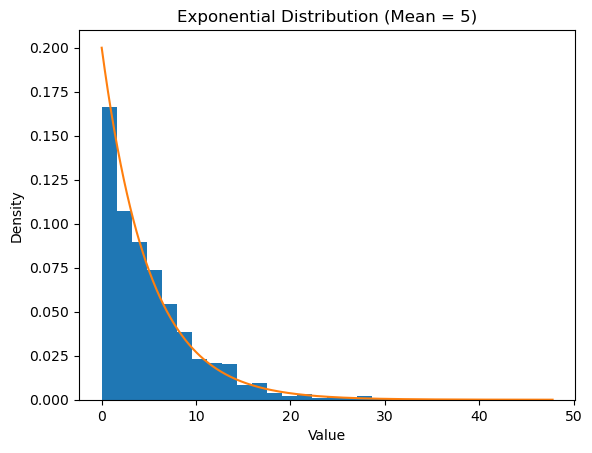

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Step a: Generate samples
mean = 5
samples = np.random.exponential(scale=mean, size=2000)

# Step b: Plot histogram
plt.figure()
count, bins, _ = plt.hist(samples, bins=30, density=True)

# PDF overlay
x = np.linspace(0, max(samples), 1000)
pdf = (1/mean) * np.exp(-x/mean)

plt.plot(x, pdf)

# Labels and title
plt.title("Exponential Distribution (Mean = 5)")
plt.xlabel("Value")
plt.ylabel("Density")

plt.show()

## Central Limit Theorem


### 6. Simulate the Central Limit Theorem by following these steps  
- a. Generate 10,000 random numbers from a uniform distribution.  
- b. Draw 1000 samples of size n = 30.  
- c. Calculate and visualize the distribution of sample means.  

Steps  

- a. Use numpy.random.uniform().  
- b. Plot both the uniform distribution and the sample mean distribution for comparison.


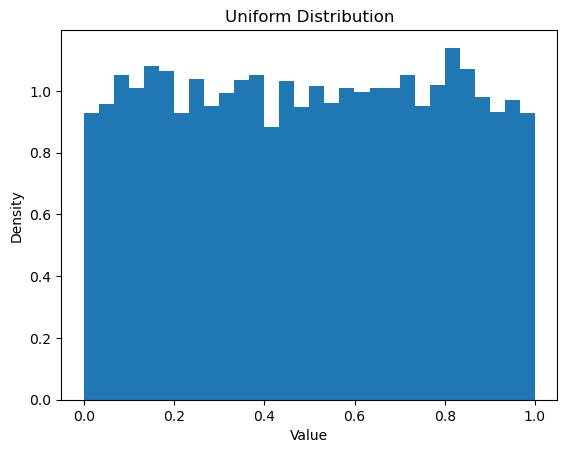

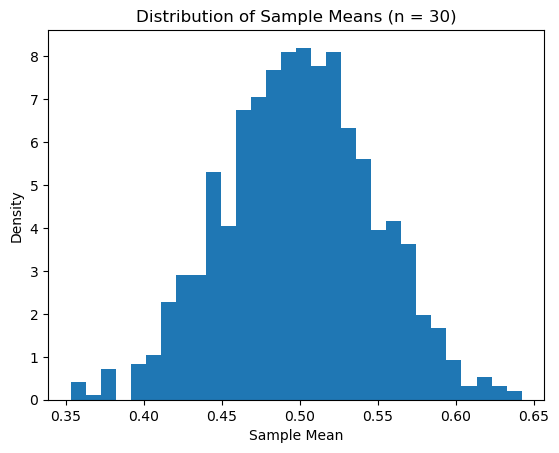

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Step a: Generate 10,000 uniform random numbers
data = np.random.uniform(0, 1, 10000)

# Step b: Draw 1000 samples of size n = 30 and compute means
sample_means = []

for _ in range(1000):
    sample = np.random.choice(data, size=30)
    sample_means.append(np.mean(sample))

# Step c1: Plot uniform distribution
plt.figure()
plt.hist(data, bins=30, density=True)
plt.title("Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

# Step c2: Plot distribution of sample means
plt.figure()
plt.hist(sample_means, bins=30, density=True)
plt.title("Distribution of Sample Means (n = 30)")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.show()